# `RenewalProcess`: why the time between events cannot be negative

A **renewal process** counts events as time passes. You give it a distribution
for the *interarrival time* -- the waiting time between one event and the next --
and it draws those waiting times independently, one after another, forever.
`N(t)` is then the number of events that have happened by time `t`.

A Poisson process is the special case where the waiting time is exponential.
`RenewalProcess` lifts that restriction: the waiting time can be any
distribution of nonnegative times, which is what makes it the building block
for queueing models (G/G/1) and actuarial risk models (Sparre Andersen).

**What this notebook shows.** Until now, nothing stopped you from handing
`RenewalProcess` a distribution that can produce a *negative* waiting time --
`Normal`, say. Nothing raised an error. You just got back a count that was
quietly wrong. This notebook reproduces that wrong output, then shows the
guard that now catches it, along with three related mistakes it catches too.

In [1]:
import numpy as np

from symbulate import *
from symbulate import distributions
from symbulate.renewal_process import RenewalProcessResult


def seed(value=42):
    """Make the draws below reproducible."""
    distributions.rng = np.random.default_rng(value)

## First, a renewal process working normally

`Gamma(shape=2, rate=1)` waiting times: always positive, averaging 2 units of
time. Each draw of the process is a whole function of continuous time, so you
can ask it for the count at any moment.

In [2]:
seed()
N = RenewalProcess(Gamma(shape=2, rate=1))
path = N.draw()
[path(t) for t in [0, 1, 2, 5, 10, 20]]

[0, 0, 0, 2, 4, 8]

That is what a count should look like: it starts at 0, it never goes down, and
each event moves it up by exactly 1 (the times above are spread far apart, so
several events can fall between two of them). Here are five sample paths.

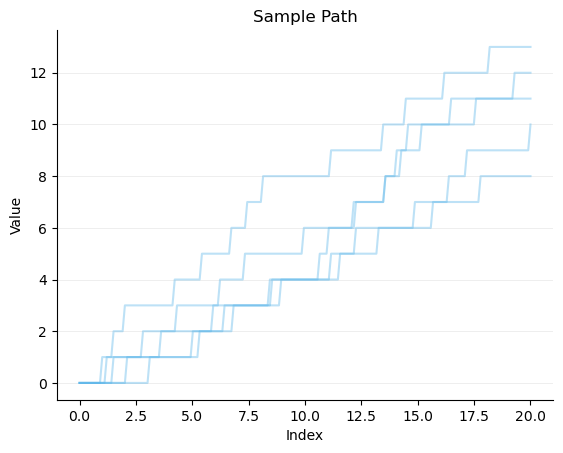

In [3]:
seed()
N.sim(5).plot(tmin=0, tmax=20)

And a check that the machinery agrees with what it generalizes: exponential
waiting times make a renewal process a Poisson process, so both should give
`E[N(4)] = rate * t = 8`.

In [4]:
seed()
renewal_mean = RenewalProcess(Exponential(rate=2))(4).sim(10000).mean()
seed()
poisson_mean = PoissonProcess(rate=2)(4).sim(10000).mean()
round(renewal_mean, 3), round(poisson_mean, 3)

(7.999, 7.999)

## The bug: a negative waiting time

A negative waiting time means the next event happens *before* the one it
follows. The events come out of chronological order, and the counting function
-- which walks the waiting times in the order they were drawn, adding them up --
loses track of how many events have actually happened.

Below is exactly what `RenewalProcess(Normal(mean=1, sd=2))` used to do
internally: draw waiting times from a distribution that is often negative, and
accumulate them. (`RenewalProcessResult` is the internal sample-path object; it
takes whatever times it is handed, which is why the guard belongs one level up,
at the probability space.)

In [5]:
seed()
waiting_times = [float(x) for x in (Normal(mean=1, sd=2) ** 12).draw()]
[round(x, 2) for x in waiting_times]

[1.61, -1.08, 2.5, 2.88, -2.9, -1.6, 1.26, 0.37, 0.97, -0.71, 2.76, 2.56]

Four of those twelve waiting times are negative. Adding them up gives the time
each event happens -- and notice these are not in increasing order:

In [6]:
event_times = [float(s) for s in np.cumsum(waiting_times)]
[round(s, 2) for s in event_times]

[1.61, 0.53, 3.03, 5.91, 3.01, 1.41, 2.66, 3.03, 3.99, 3.29, 6.05, 8.6]

Now compare the count the process reports against the number of events that
have genuinely happened by each time `t`:

In [7]:
broken = RenewalProcessResult(waiting_times)
print(" t   reported N(t)   events that really happened by t")
for t in range(0, 9):
    really_happened = sum(1 for s in event_times if s <= t)
    print(f"{t:2}        {broken(t):3}                    {really_happened:3}")

 t   reported N(t)   events that really happened by t
 0          0                      0
 1          0                      1
 2          2                      3
 3          2                      4
 4          3                      9
 5          3                      9
 6         10                     10
 7         11                     11
 8         11                     11


The two columns disagree almost everywhere:

- At `t = 1` the process reports **0 events**, but an event already happened at
  time 0.53.
- At `t = 4` it reports **3**, while 9 of the event times are at or before 4.
- Between `t = 4` and `t = 6` the reported count jumps from **3 to 10**,
  skipping 4 through 9 entirely. There is no time at which this process
  reports 5 events.

Nothing here raised an error, printed a warning, or produced an obviously
strange number. That is what made it worth fixing: a student gets a plot and a
mean that look perfectly reasonable and are silently not a renewal process.

There is a worse version, too. If the waiting-time distribution has a
*negative* mean (`Normal(mean=-1, sd=2)`), the running total drifts downward and
may never pass the `t` you asked about -- so the count never comes back at all
and the notebook hangs.

## The fix

`RenewalProcess` now checks the waiting-time distribution before it accepts it,
the same way `PoissonProcess` has always checked that `rate > 0`. Anything that
can produce a negative time is refused, with a message that says what is wrong
and what to use instead.

In [8]:
for dist in [
    Normal(mean=5, sd=1),
    Uniform(a=-1, b=3),
    DiscreteUniform(-3, 4),
    Cauchy(),
]:
    try:
        RenewalProcess(dist)
    except ValueError as error:
        print(f"{type(dist).__name__}:\n  {error}\n")

Normal:
  interarrival_dist must never produce a negative time, but Normal can produce values as small as -inf. The time between two events is a waiting time, so it cannot be negative -- a negative waiting time would make the count of events go backwards. Try a distribution that is never negative, such as Exponential(rate=1), Gamma(shape=2, rate=1), LogNormal(0, 1), or Uniform(a=0, b=2).

Uniform:
  interarrival_dist must never produce a negative time, but Uniform can produce values as small as -1. The time between two events is a waiting time, so it cannot be negative -- a negative waiting time would make the count of events go backwards. Try a distribution that is never negative, such as Exponential(rate=1), Gamma(shape=2, rate=1), LogNormal(0, 1), or Uniform(a=0, b=2).

DiscreteUniform:
  interarrival_dist must never produce a negative time, but DiscreteUniform can produce values as small as -3. The time between two events is a waiting time, so it cannot be negative -- a negative wa

`Normal(mean=5, sd=1)` is worth a second look: negative values are five standard
deviations out, so a small simulation might never draw one and everything would
appear to work -- right up until a larger run did. The check reads the
distribution's *support* rather than sampling from it, so rarity does not let it
slip through.

The support comes from SciPy, through `Distribution._support()`, which means a
distribution added to Symbulate tomorrow is checked correctly with no extra
code.

### The same invariant from the other side: waiting times that are always zero

A distribution that can only produce 0 puts infinitely many events at time 0,
so the running total never passes any `t` and the count never finishes
computing. `RenewalProcess(Poisson(0))` used to hang; now it explains itself.

In [9]:
for dist in [Poisson(0), DiscreteUniform(0, 0)]:
    try:
        RenewalProcess(dist)
    except ValueError as error:
        print(f"{type(dist).__name__}:\n  {error}\n")

Poisson:
  interarrival_dist must sometimes produce a positive time, but Poisson produces a time of 0 on every draw, which would put infinitely many events at time 0. Choose a distribution with an average waiting time greater than 0, such as Exponential(rate=1) or Gamma(shape=2, rate=1).

DiscreteUniform:
  interarrival_dist must sometimes produce a positive time, but DiscreteUniform produces a time of 0 on every draw, which would put infinitely many events at time 0. Choose a distribution with an average waiting time greater than 0, such as Exponential(rate=1) or Gamma(shape=2, rate=1).



### Two mistakes about the argument itself

Passing a *rate* instead of a distribution is an easy slip, given how
`PoissonProcess` is written -- so that specific case gets pointed at
`PoissonProcess`. And a multivariate distribution produces a whole vector per
draw, which is not a single waiting time.

In [10]:
for bad in [2, BivariateNormal(mean1=1, mean2=1)]:
    try:
        RenewalProcess(bad)
    except TypeError as error:
        print(f"{error}\n")

interarrival_dist must be a Symbulate distribution describing the time between events, such as Exponential(rate=1), Gamma(shape=2, rate=1), or Uniform(a=0, b=2). You gave int. (If you wanted events arriving at rate 2, use PoissonProcess(rate=2) or RenewalProcess(Exponential(rate=2)).)

interarrival_dist must be a distribution of single numbers, but BivariateNormal produces a whole vector of numbers on each draw. A renewal process needs one waiting time per event. Try a one-number distribution such as Exponential(rate=1) or Gamma(shape=2, rate=1).



## What still works

Every distribution of nonnegative times is accepted, including a point mass.
`LogNormal(0, 0)` is a point mass at `exp(0) = 1`, so events land exactly at
times 1, 2, 3, ... and the count at `t = 3.5` is exactly 3 -- a case with no
randomness in it at all, which makes it a good sanity check.

In [11]:
for label, dist in [
    ("Exponential(rate=1)", Exponential(rate=1)),
    ("Gamma(shape=2, rate=1)", Gamma(shape=2, rate=1)),
    ("Uniform(a=0, b=2)", Uniform(a=0, b=2)),
    ("LogNormal(0, 1)", LogNormal(0, 1)),
    ("Weibull(shape=2, scale=1)", Weibull(shape=2, scale=1)),
    ("Poisson(2)", Poisson(2)),
    ("LogNormal(0, 0)", LogNormal(0, 0)),
]:
    seed()
    path = RenewalProcess(dist).draw()
    print(f"{label:26} N(3.5) = {path(3.5)}")

Exponential(rate=1)        N(3.5) = 1
Gamma(shape=2, rate=1)     N(3.5) = 1
Uniform(a=0, b=2)          N(3.5) = 2
LogNormal(0, 1)            N(3.5) = 2
Weibull(shape=2, scale=1)  N(3.5) = 3
Poisson(2)                 N(3.5) = 0
LogNormal(0, 0)            N(3.5) = 3


One case the check cannot decide: a point mass written as a degenerate range,
like `Uniform(a=2, b=2)`. SciPy reports its support as `(nan, nan)`, so there is
no bound to compare against and the distribution is accepted on the assumption
that the value is positive. Accepting is the right call -- `Uniform(a=2, b=2)`
is a perfectly good waiting-time distribution -- but it does mean the one bad
case of that shape, `Uniform(a=0, b=0)`, still hangs rather than raising. That
is a degenerate-parameter problem in `Uniform` itself (it allows `a == b`) and
is better fixed there. **Not run here, because it would hang the notebook.**

## Confirming the counts are right

Validation only rules out bad input; it does not prove the good input gives the
right answer. For any renewal process, the expected count is

$$E[N(t)] = \sum_{k \ge 1} P(S_k \le t)$$

where `S_k` is the sum of the first `k` waiting times. With `Gamma(shape=2,
rate=1)` waiting times, `S_k` is `Gamma(shape=2k, rate=1)`, so the exact answer
is computable and the simulation should land on it.

In [12]:
import scipy.stats as stats

t = 10
exact = sum(stats.gamma(a=2 * k, scale=1).cdf(t) for k in range(1, 60))

seed()
simulated = RenewalProcess(Gamma(shape=2, rate=1))(t).sim(10000).mean()

print(f"exact      E[N({t})] = {exact:.3f}")
print(f"simulated  E[N({t})] = {simulated:.3f}")

exact      E[N(10)] = 4.750
simulated  E[N(10)] = 4.757


## Where this lives

- `symbulate/renewal_process.py` -- `RenewalProcess`,
  `RenewalProcessProbabilitySpace`, `RenewalProcessResult`, and the validation
  shown above.
- `symbulate/tests/test_renewal_process.py` -- 41 tests, including regression
  tests for each rejection in this notebook.
- `MODEL-DECISIONS.md`, "Decision: `RenewalProcess` Interarrival-Distribution
  Validation" -- why the check reads the support instead of sampling, why it
  raises instead of warning, and the `Uniform(a=b)` limitation.